# <b>First Stage: Initial Simulations on iCH360</b> 

<div style='text-align: justify'>At first, to comparison between strains, we will demonstrate the capacity of NADH production by iCH360 model without HydABC complex, under aerobic and anaerobic conditions.</div><br>

<div style='text-align: justify'><b>Note 1:</b> For this first stage of analysis on EC_iCH360, biomass will be set as objective in all simulations. Also, glucose can be assumed as the only carbon source.</div><br>

<div style='text-align: justify'><b>Note 2:</b> To visualize escher maps, download the <b>escher.yml</b> file and create the environment from it. Alternatively, you may install the required packages individually, as implemented in this workflow. All linear programming (LP) problems were solved using the Gurobi solver.</div>

In [1]:
# model handling and loading
import cobra
from cobra.io import load_json_model

# data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Functions constantly used on codes
import functions as f

In [3]:
# model loading
# model = load_json_model('../Models/EC_iCH360.json')

In [4]:
model

Name,EC_iCH360
Memory address,7fdcd56df700
Number of metabolites,305
Number of reactions,505
Number of genes,356
Number of groups,0
Objective expression,1.0*Biomass_fw - 1.0*Biomass_fw_reverse_bf19d
Compartments,"cytosol, extracellular space, periplasm"


# 1. iCH360 Initial Simulations 

## 1.1 Biomass Formation and NADH/ATP Production and Consumption under Aerobic Conditions

In [3]:
model_aero = model.copy()

Read LP format model from file /tmp/tmppkoh1iqc.lp
Reading time = 0.00 seconds
: 305 rows, 1010 columns, 4816 nonzeros


In [4]:
# biomass production
solution_aero = model_aero.optimize()
print(f'Biomass production under aerobic conditions: {solution_aero.objective_value:.4f} h\u207B\u00B9')

Biomass production under aerobic conditions: 0.6167 h⁻¹


In [5]:
# NADH consumption and production

# Here, we present only the enzymes with fluxes that account for more than 1% of the total NADH consumption or production.
# This approach avoids including reactions with negligible fluxes. The threshold can be adjusted using the variable limit.

limit = 0.01
metabolite = 'nadh_c'

df_nadh_aero = f.metabolite_df(model_aero,solution_aero,metabolite,limit)
display(df_nadh_aero)

total_nadh = sum(model_aero.metabolites.get_by_id(metabolite).summary(solution_aero).producing_flux['flux'])
print(f'NADH production under aerobic conditions: {total_nadh:.4f} mmol gDW\u207B\u00B9 h\u207B\u00B9')

,flux,percent
NADH16pp_fw,-27.557075,0.973397
AKGDH_fw,0.323523,0.011428
MDH_fw,0.965824,0.034116
PGCD_fw,1.092487,0.038590
PDH_fw,10.062283,0.355429
GAPD_fw,15.203114,0.537019


NADH production under aerobic conditions: 28.3102 mmol gDW⁻¹ h⁻¹


In [7]:
# ATP consumption and production

metabolite = 'atp_c'

df_atp_aero = f.metabolite_df(model_aero,solution_aero,metabolite,limit)
display(df_atp_aero)

total_atp = sum(model_aero.metabolites.get_by_id(metabolite).summary(solution_aero).producing_flux['flux'])
print(f'ATP production under aerobic conditions: {total_atp:.4f} mmol gDW\u207B\u00B9 h\u207B\u00B9')

,flux,percent
Biomass_fw,-47.003349,0.655780
PFK_fw,-7.021767,0.097966
ATPM_fw,-6.860000,0.095709
GLNS_fw,-1.500036,0.020928
ACCOAC_fw,-1.488216,0.020763
ADK1_fw,-1.392758,0.019431
CBPS_fw,-0.772786,0.010782
PYK_fw,2.653265,0.037018
ACKr_bw,6.700568,0.093485
PGK_bw,15.203114,0.212110


ATP production under aerobic conditions: 71.6755 mmol gDW⁻¹ h⁻¹


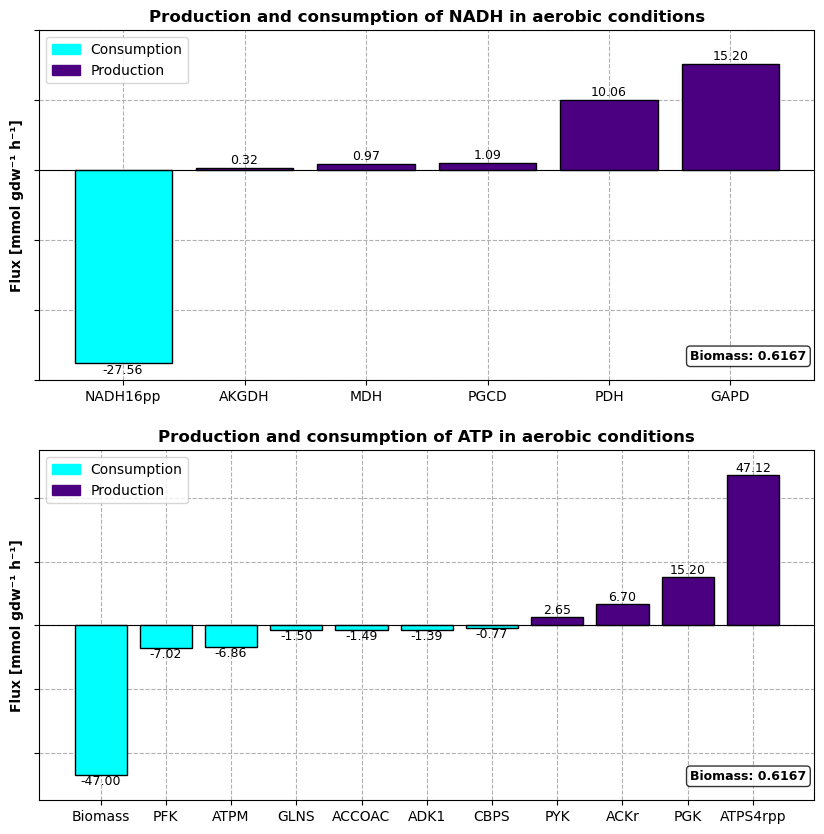

In [8]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10,10))
gs = GridSpec(2, 1,figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

f.plot_df(df_nadh_aero, 
          "Production and consumption of NADH in aerobic conditions", 
          [-30,20], 
          round(solution_aero.objective_value,4), 
          ax=ax1)

f.plot_df(df_atp_aero, 
          "Production and consumption of ATP in aerobic conditions", 
          [-55,55], 
          round(solution_aero.objective_value,4), 
          ax=ax2)
#fig.savefig('../Images/ATP_NADH_Aero.png',dpi=1200)

### Visualization

<div style='text-align: justify'><b>Note: </b>To visualize the metabolism of EC_iCH360, we will use the Escherichia_coli_iCH360 model, as the available JSON file corresponds to Escherichia_coli_iCH360 rather than EC_iCH360 (see: <a href="https://github.com/marco-corrao/iCH360">iCH360</a>) (<a href="https://doi.org/10.1371/journal.pcbi.1013564">Corrao et al., 2025</a>). However, all subsequent simulations and modifications will be performed using the EC_iCH360 model.</div>

In [9]:
# Tools for metabolic visualization
import escher
from IPython.display import display
from escher import Builder

In [10]:
model_visualization = load_json_model('../Models/Escherichia_coli_iCH360.json')

In [11]:
model_visualization_aero = model_visualization.copy()
sol_vis_aero = model_visualization_aero.optimize() 

escher_builder = escher.Builder(
    map_json='../Visualization/full_map.json', 
    reaction_scale=[{'type': 'min', 'color': '#0000ff', 'size': 10}, 
               {'type': 'mean', 'color': '#551a8b', 'size': 20},
               {'type': 'max', 'color': '#ff0000', 'size': 40}],

    #hide_secondary_metabolites = True,
    reaction_data = sol_vis_aero.fluxes,

)
display(escher_builder)

Read LP format model from file /tmp/tmpvd7blfkm.lp
Reading time = 0.00 seconds
: 304 rows, 698 columns, 2988 nonzeros


Builder(reaction_data={'NDPK5': np.float64(0.02338664548709677), 'SHK3Dr': np.float64(0.3289417341554844), 'ND…

In [12]:
# NADH and ATP production/consumption in iCH360 model
df_nadh_vis = f.metabolite_df(model_visualization_aero,sol_vis_aero,'nadh_c',0.01)
display(df_nadh_vis)

df_atp_vis = f.metabolite_df(model_visualization_aero,sol_vis_aero,'atp_c',0.01)
display(df_atp_vis)

,flux,percent
NADH16pp,-39.266265,0.950970
PGCD,1.533554,0.037140
AKGDH,5.796026,0.140371
MDH,6.697641,0.162207
PDH,9.558282,0.231487
GAPD,16.774607,0.406256


,flux,percent
Biomass,-65.979886,0.683103
PFK,-8.099202,0.083853
ATPM,-6.860000,0.071023
GLNS,-2.105641,0.021800
ACCOAC,-2.089049,0.021628
ADK1,-1.955052,0.020241
CBPS,-1.084781,0.011231
PYK,1.967015,0.020365
SUCOAS,5.341888,0.055306
PGK,16.774607,0.173671


### Important points

#### Production and consumption of NADH
<ol>
    <li>Despite the differences in flux distributions between iCH360 and EC_iCH360, NADH production is distributed approximately equally between the reductive branch of the TCA cycle and the activity of glyceraldehyde-3-phosphate dehydrogenase (GAPD) in glycolysis, consistent with reports in the literature.</li><br>
    <li>Similarly, NADH consumption occurs predominantly through NADH dehydrogenase activity (NADH16pp), a key component in the generation of the proton motive force.</li>
</ol>

#### Production and consumption of ATP
<ol>
    <li>Regarding ATP production, ATP synthase (ATPS4rpp) accounts for the majority of the ATP-generating flux, supported by the high flux through the NADH16pp reaction. In addition, phosphoglycerate kinase (PGK) contributes to ATP formation via substrate-level phosphorylation.</li><br>
    <li>On the other hand, ATP consumption is primarily associated with biomass formation, followed by the activity of phosphofructokinase (PFK) and ATP maintenance reactions, which are essential for non-growth-associated functions.</li>
</ol>

<div style='text-align: justify'>Therefore, based on the results described above, we highlight the reliability of the iCH360 model in predicting the expected metabolic behavior of <i>E. coli</i> under aerobic conditions.</div> 



## 1.2 Biomass Formation and NADH/ATP Production and Consumption under Anaerobic Conditions

In [13]:
model_anaero = model.copy()

Read LP format model from file /tmp/tmp2hf9urot.lp
Reading time = 0.00 seconds
: 305 rows, 1010 columns, 4816 nonzeros


In [14]:
# Simulating an anaerobic environment
model_anaero.reactions.get_by_id('EX_o2_e_bw').bounds = (0,0)

In [15]:
# biomass production
solution_anaero = model_anaero.optimize()
print(f'Biomass production under anaerobic conditions: {solution_anaero.objective_value:.4f} h\u207B\u00B9')

Biomass production under anaerobic conditions: 0.1032 h⁻¹


In [16]:
# NADH consumption and production

# Here, we present only the enzymes with fluxes that account for more than 1% of the total NADH consumption or production.
# This approach avoids including reactions with negligible fluxes. The threshold can be adjusted using the variable limit.

limit = 0.01
metabolite = 'nadh_c'

df_nadh_anaero = f.metabolite_df(model_anaero,solution_anaero,metabolite,limit)
display(df_nadh_anaero)

total_nadh = sum(model_anaero.metabolites.get_by_id(metabolite).summary(solution_anaero).producing_flux['flux'])
print(f'NADH production under anaerobic conditions: {total_nadh:.4f} mmol gDW\u207B\u00B9 h\u207B\u00B9')

,flux,percent
LDH_D_bw,-16.816799,0.907694
THD2pp_fw,-1.455414,0.078557
GAPD_fw,18.233165,0.984143


NADH production under anaerobic conditions: 18.5269 mmol gDW⁻¹ h⁻¹


In [17]:
# ATP consumption and production

metabolite = 'atp_c'

df_atp_anaero = f.metabolite_df(model_anaero,solution_anaero,metabolite,limit)
display(df_atp_anaero)

total_atp = sum(model_anaero.metabolites.get_by_id(metabolite).summary(solution_anaero).producing_flux['flux'])
print(f'ATP production under anaerobic conditions: {total_atp:.4f} mmol gDW\u207B\u00B9 h\u207B\u00B9')

,flux,percent
PFK_fw,-9.140957,0.344480
Biomass_fw,-7.866168,0.296439
ATPM_fw,-6.860000,0.258521
ATPS4rpp_bw,-0.748554,0.028209
PYK_fw,8.302382,0.312878
PGK_bw,18.233165,0.687122


ATP production under anaerobic conditions: 26.5355 mmol gDW⁻¹ h⁻¹


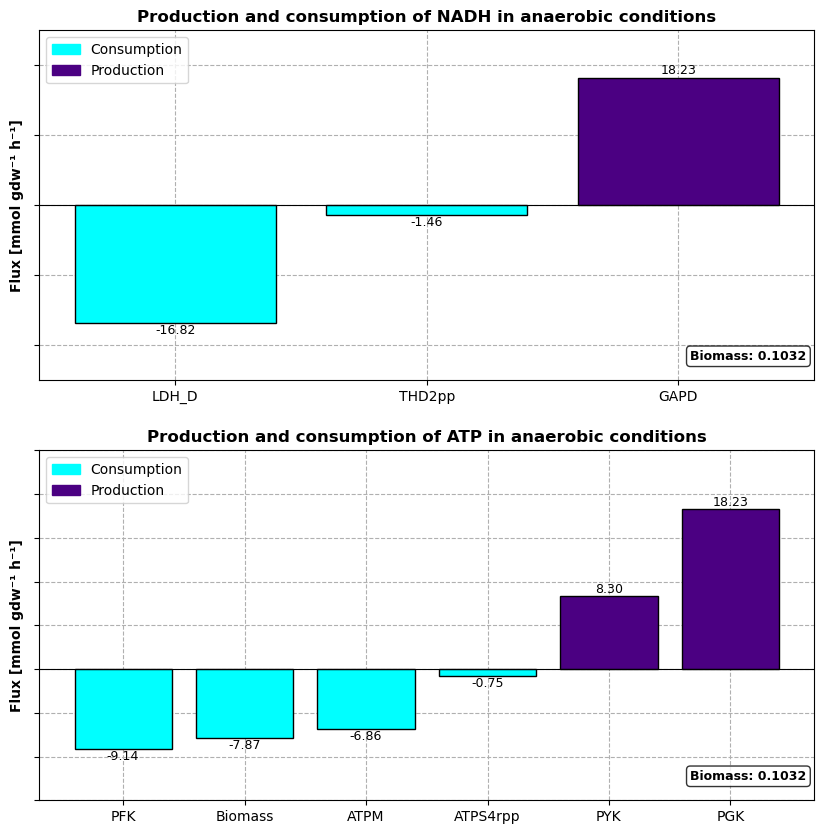

In [18]:
fig = plt.figure(figsize=(10,10))
gs = GridSpec(2, 1,figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

f.plot_df(df_nadh_anaero, 
          "Production and consumption of NADH in anaerobic conditions", 
          [-25,25], 
          round(solution_anaero.objective_value,4), 
          ax=ax1)

f.plot_df(df_atp_anaero, 
          "Production and consumption of ATP in anaerobic conditions", 
          [-15,25], 
          round(solution_anaero.objective_value,4), 
          ax=ax2)
#fig.savefig('../Images/ATP_NADH_Anaero.png',dpi=1200)

### Visualization

In [19]:
model_visualization_anaero = model_visualization.copy()
model_visualization_anaero.reactions.get_by_id('EX_o2_e').bounds = (0,0)

sol_vis_anaero = model_visualization_anaero.optimize() 

escher_builder = escher.Builder(
    map_json='../Visualization/full_map.json', 
    reaction_scale=[{'type': 'min', 'color': '#0000ff', 'size': 10}, 
               {'type': 'mean', 'color': '#551a8b', 'size': 20},
               {'type': 'max', 'color': '#ff0000', 'size': 40}],

    #hide_secondary_metabolites = True,
    reaction_data = sol_vis_anaero.fluxes,

)
display(escher_builder)

Read LP format model from file /tmp/tmpanl9qa4e.lp
Reading time = 0.00 seconds
: 304 rows, 698 columns, 2988 nonzeros


Builder(reaction_data={'NDPK5': np.float64(0.004230322245219115), 'SHK3Dr': np.float64(0.059501031738247945), …

In [20]:
# NADH and ATP production/consumption in iCH360 model
df_nadh_vis = f.metabolite_df(model_visualization_anaero,sol_vis_anaero,'nadh_c',0.01)
display(df_nadh_vis)

df_atp_vis = f.metabolite_df(model_visualization_anaero,sol_vis_anaero,'atp_c',0.01)
display(df_atp_vis)

,flux,percent
ALCD2x,-8.759780,0.434059
ACALD,-8.759780,0.434059
THD2pp,-2.295299,0.113735
PGCD,0.277399,0.013745
GAPD,19.624384,0.972416


,flux,percent
Biomass,-11.934853,0.322018
PFK,-9.863985,0.266143
ATPM,-6.860000,0.185092
ATPS4rpp,-5.581830,0.150605
GLNS,-0.380882,0.010277
ACCOAC,-0.377880,0.010196
PYK,8.702604,0.234808
ACKr,8.735676,0.235700
PGK,19.624384,0.529492


### Important points

#### Production and consumption of NADH
<ol>
    <li>Under $O_2$ depleted conditions, <i>E. coli</i> metabolism is reorganized toward the activation of fermentative pathways. In the EC_iCH360 model, homolactic fermentation predominates, with lactate dehydrogenase (LDH) accounting for approximately 90% of NADH consumption. In contrast, simulations with the iCH360 model indicate alcoholic fermentation under anaerobic conditions, with NADH directed toward ethanol production via acetaldehyde dehydrogenase (ACALD) and alcohol dehydrogenase (ALCD2x).</li><br>
    <li>In contrast to NADH consumption, both models indicate that under anaerobic conditions, NADH production arises almost entirely from glyceraldehyde-3-phosphate dehydrogenase (GAPD) activity. This reflects the maintenance of glycolytic flux, sustained by NADH reoxidation through fermentative pathways..</li>
</ol>

#### Production and consumption of ATP
<ol>
    <li>In the absence of oxidative phosphorylation, ATP production is restricted to glycolysis in both the iCH360 and EC_iCH360 models. Phosphoglycerate kinase (PGK) and pyruvate kinase (PYK) together account for approximately 80% of total ATP production.</li><br>
    <li>In addition to the previously cited ATP consuming processes (biomass production and non-growth associated processes), we highlight the reversal of the ATP synthase reaction, which hydrolyzes ATP to maintain the $H^+$ gradient.</li>
</ol>

<div style='text-align: justify'>Thus, consistent with experimental evidence, the model correctly predicts the activation of fermentative pathways under anaerobic conditions, accompanied by reduced NADH and ATP production and, consequently, a lower biomass yield compared with aerobic growth. </div> 

# <b>End of Part 1!</b>